In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis, KDTree, BallTree
from sklearn.datasets import load_iris, make_classification, make_regression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
X, y = load_iris(return_X_y=True)
X = X[:, [0, 2]]

In [3]:
k = 15

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=15)

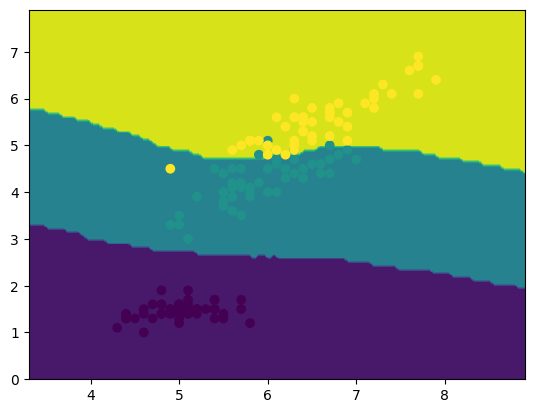

In [4]:
DecisionBoundaryDisplay.from_estimator(knn, X)
plt.scatter(*X.T, c=y)

## Зависимость точности от k

In [5]:
X, y = load_iris(return_X_y=True)

In [6]:
k_values = np.arange(1, 31)
k_values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [7]:
X.shape

(150, 4)

In [8]:
cv_folds = 5

mean_scores = []
std_scores = []
for k in k_values:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Кросс-валидация с разбиением на 5 частей
    scores = cross_val_score(knn, X, y, cv=cv_folds, scoring='accuracy')
    
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())
    
    print(f"k={k:2d}: Средняя точность = {scores.mean():.4f} (+/- {scores.std():.4f})")

k= 1: Средняя точность = 0.9600 (+/- 0.0249)
k= 2: Средняя точность = 0.9467 (+/- 0.0340)
k= 3: Средняя точность = 0.9667 (+/- 0.0211)
k= 4: Средняя точность = 0.9733 (+/- 0.0133)
k= 5: Средняя точность = 0.9733 (+/- 0.0249)
k= 6: Средняя точность = 0.9800 (+/- 0.0163)
k= 7: Средняя точность = 0.9800 (+/- 0.0163)
k= 8: Средняя точность = 0.9667 (+/- 0.0298)
k= 9: Средняя точность = 0.9733 (+/- 0.0249)
k=10: Средняя точность = 0.9800 (+/- 0.0267)
k=11: Средняя точность = 0.9800 (+/- 0.0267)
k=12: Средняя точность = 0.9800 (+/- 0.0267)
k=13: Средняя точность = 0.9733 (+/- 0.0249)
k=14: Средняя точность = 0.9667 (+/- 0.0298)
k=15: Средняя точность = 0.9667 (+/- 0.0298)
k=16: Средняя точность = 0.9667 (+/- 0.0298)
k=17: Средняя точность = 0.9667 (+/- 0.0298)
k=18: Средняя точность = 0.9667 (+/- 0.0298)
k=19: Средняя точность = 0.9667 (+/- 0.0298)
k=20: Средняя точность = 0.9600 (+/- 0.0327)
k=21: Средняя точность = 0.9667 (+/- 0.0298)
k=22: Средняя точность = 0.9600 (+/- 0.0327)
k=23: Сред

Text(0, 0.5, 'скор')

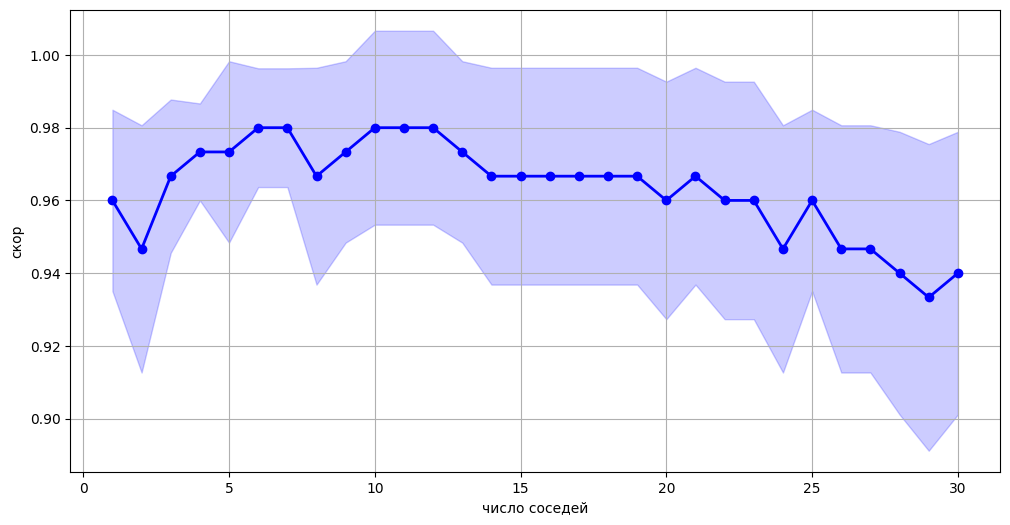

In [9]:
plt.figure(figsize=(12, 6))

# График средней точности
plt.plot(k_values, mean_scores, 'b-o', linewidth=2, markersize=6, label='Средняя точность')

# Добавляем полосу стандартного отклонения
plt.fill_between(k_values, 
                 np.array(mean_scores) - np.array(std_scores),
                 np.array(mean_scores) + np.array(std_scores),
                 alpha=0.2, color='blue', label='±1 std')
plt.grid()
plt.xlabel('число соседей')
plt.ylabel('скор')

# KNN со случайными признаками

In [10]:
mean_scale = np.mean(np.std(X, axis=0))
random_feature = np.random.normal(0, mean_scale, (X.shape[0], 1))
X_noised = np.hstack([X, random_feature])
X_noised.shape

(150, 5)

In [11]:
cv_folds = 5

mean_scores_noise = []
std_scores_noise = []
for k in k_values:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Кросс-валидация с разбиением на 5 частей
    scores = cross_val_score(knn, X_noised, y, cv=cv_folds, scoring='accuracy')
    
    mean_scores_noise.append(scores.mean())
    std_scores_noise.append(scores.std())
    
    print(f"k={k:2d}: Средняя точность = {scores.mean():.4f} (+/- {scores.std():.4f})")

k= 1: Средняя точность = 0.9333 (+/- 0.0471)
k= 2: Средняя точность = 0.9400 (+/- 0.0249)
k= 3: Средняя точность = 0.9400 (+/- 0.0490)
k= 4: Средняя точность = 0.9333 (+/- 0.0422)
k= 5: Средняя точность = 0.9467 (+/- 0.0452)
k= 6: Средняя точность = 0.9467 (+/- 0.0452)
k= 7: Средняя точность = 0.9400 (+/- 0.0573)
k= 8: Средняя точность = 0.9400 (+/- 0.0442)
k= 9: Средняя точность = 0.9400 (+/- 0.0442)
k=10: Средняя точность = 0.9200 (+/- 0.0542)
k=11: Средняя точность = 0.9333 (+/- 0.0422)
k=12: Средняя точность = 0.9467 (+/- 0.0340)
k=13: Средняя точность = 0.9467 (+/- 0.0267)
k=14: Средняя точность = 0.9533 (+/- 0.0267)
k=15: Средняя точность = 0.9467 (+/- 0.0340)
k=16: Средняя точность = 0.9400 (+/- 0.0249)
k=17: Средняя точность = 0.9333 (+/- 0.0298)
k=18: Средняя точность = 0.9200 (+/- 0.0340)
k=19: Средняя точность = 0.9467 (+/- 0.0340)
k=20: Средняя точность = 0.9333 (+/- 0.0298)
k=21: Средняя точность = 0.9400 (+/- 0.0442)
k=22: Средняя точность = 0.9333 (+/- 0.0471)
k=23: Сред

Text(0, 0.5, 'скор')

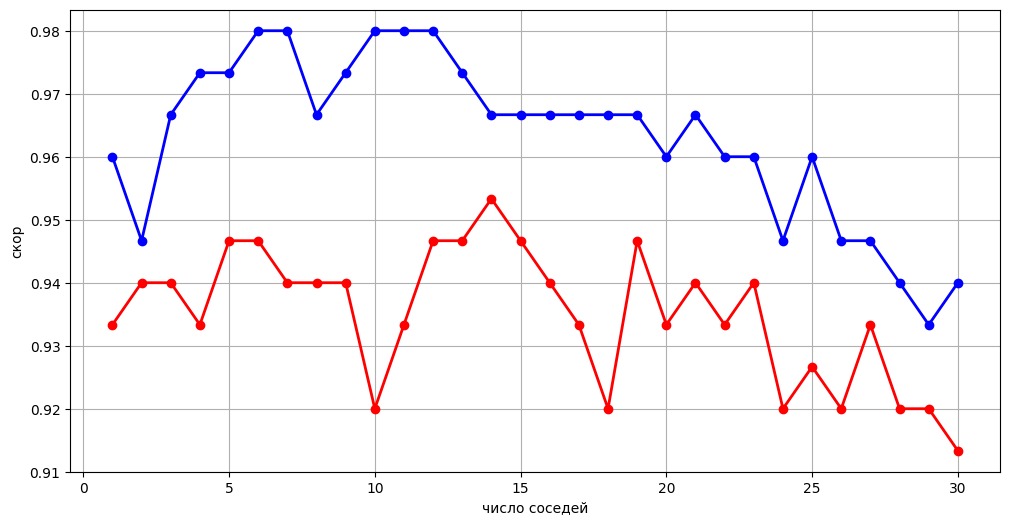

In [12]:
plt.figure(figsize=(12, 6))

# График средней точности
plt.plot(k_values, mean_scores, 'b-o', linewidth=2, markersize=6, label='Средняя точность')
plt.plot(k_values, mean_scores_noise, 'r-o', linewidth=2, markersize=6, label='Средняя точность зашумлённая')

plt.grid()
plt.xlabel('число соседей')
plt.ylabel('скор')

# KNN без нормализации

In [13]:
# Генерируем синтетические данные
np.random.seed(42)
n_samples = 300

# Признак 1: маленький масштаб (0-10)
feature1 = np.random.uniform(0, 10, n_samples)

# Признак 2: большой масштаб (0-1000)
feature2 = np.random.uniform(0, 1000, n_samples)

# Целевая переменная: зависит от обоих признаков
y = ((feature1 > 5) & (feature2 > 500)).astype(int)

X = np.column_stack([feature1, feature2])

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# KNN без нормализации
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
y_pred_raw = knn_raw.predict(X_test)
accuracy_raw = accuracy_score(y_test, y_pred_raw)

# KNN с нормализацией
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform на обучающих
X_test_scaled = scaler.transform(X_test)        # только transform на тестовых

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

# Вывод результатов
print(f"Точность без нормализации: {accuracy_raw:.3f}")
print(f"Точность с нормализацией: {accuracy_scaled:.3f}")

Точность без нормализации: 0.800
Точность с нормализацией: 0.989


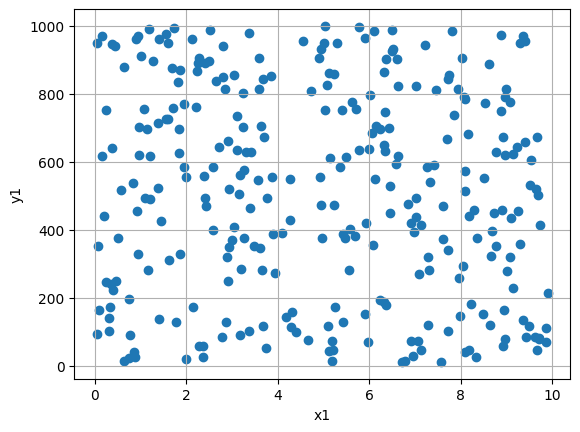

In [14]:
plt.scatter(*X.T)
plt.xlabel('x1')
plt.ylabel('y1')
plt.grid()

# NCA

In [15]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.7, random_state=42)

In [16]:
nca = NeighborhoodComponentsAnalysis(random_state=42)
nca.fit(X_train, y_train)

NeighborhoodComponentsAnalysis(random_state=42)

https://scikit-learn.org/stable/auto_examples/neighbors/plot_nca_illustration.html#sphx-glr-auto-examples-neighbors-plot-nca-illustration-py

In [17]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [18]:
print(knn.score(X_test, y_test))
knn.fit(nca.transform(X_train), y_train)
print(knn.score(nca.transform(X_test), y_test))

0.9333333333333333
0.9619047619047619


# LMNN

In [36]:
# pip install metric_learn

In [37]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import metric_learn

In [38]:
X, y = make_classification(n_samples=100, n_classes=3, n_clusters_per_class=2,
                           n_informative=3, class_sep=4., n_features=5,
                           n_redundant=0, shuffle=True,
                           scale=[1, 1, 20, 20, 20])

In [39]:
def plot_tsne(X, y, colormap=plt.cm.Paired):
    # plt.figure(figsize=(8, 6))

    # clean the figure
    plt.clf()

    tsne = TSNE()
    X_embedded = tsne.fit_transform(X)
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap=colormap)

    plt.xticks(())
    plt.yticks(())
    plt.show()

In [41]:
def plot_pca(X, y, colormap=plt.cm.Paired):
    # plt.figure(figsize=(8, 6))

    # clean the figure
    plt.clf()

    pca = PCA(n_components=2)
    X_embedded = pca.fit_transform(X)
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap=colormap)

    plt.xticks(())
    plt.yticks(())
    plt.show()

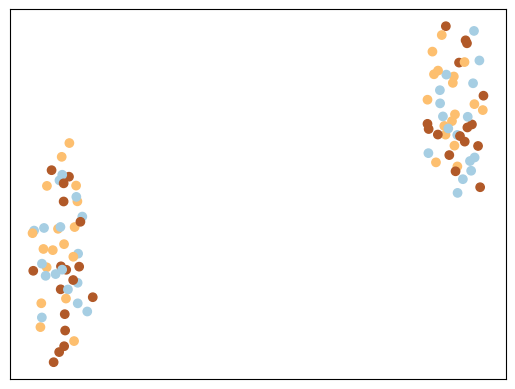

In [42]:
plot_tsne(X, y)

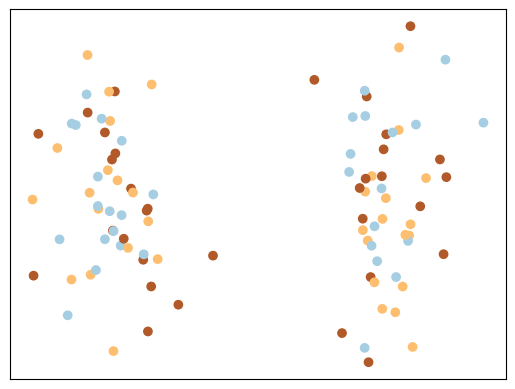

In [43]:
plot_pca(X, y)

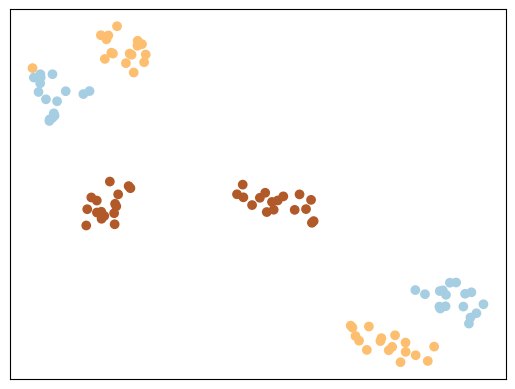

In [44]:
lmnn = metric_learn.LMNN(n_neighbors=5, learn_rate=1e-6)
lmnn.fit(X, y)
X_lmnn = lmnn.transform(X)
plot_tsne(X_lmnn, y)

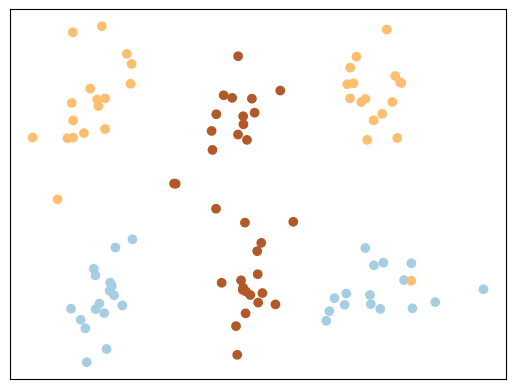

In [45]:
plot_pca(X_lmnn, y)

# Ближайшие точки

https://github.com/facebookresearch/faiss

https://github.com/nmslib/hnswlib

In [28]:
import faiss

In [29]:
d = 64                           # dimension
nb = 100000                      # database size
nq = 10000                       # nb of queries
np.random.seed(1234)             # make reproducible

In [30]:
xb = np.random.random((nb, d)).astype('float32')
xb[:, 0] += np.arange(nb) / 1000.

xq = np.random.random((nq, d)).astype('float32')
xq[:, 0] += np.arange(nq) / 1000.

In [31]:
index = faiss.IndexFlatL2(d)   # build the index
print(index.is_trained)
index.add(xb)                  # add vectors to the index
print(index.ntotal)

True
100000


In [32]:
k = 4                          # we want to see 4 nearest neighbors
D, I = index.search(xb[:5], k) # sanity check

In [33]:
%%time
D, I = index.search(xq, k)     # actual search
print(I[:5])                   # neighbors of the 5 first queries
print(I[-5:])                  # neighbors of the 5 last queries

[[ 381  207  210  477]
 [ 526  911  142   72]
 [ 838  527 1290  425]
 [ 196  184  164  359]
 [ 526  377  120  425]]
[[ 9900 10500  9309  9831]
 [11055 10895 10812 11321]
 [11353 11103 10164  9787]
 [10571 10664 10632  9638]
 [ 9628  9554 10036  9582]]
CPU times: user 22.9 s, sys: 29.7 ms, total: 22.9 s
Wall time: 2.05 s


In [34]:
%%time
kdtree = KDTree(xb, leaf_size=30)
dist, ind = kdtree.query(xq, k=k)
print(ind[:5])                   # neighbors of the 5 first queries
print(ind[-5:])                  # neighbors of the 5 last queries

[[ 381  207  210  477]
 [ 526  911  142   72]
 [ 838  527 1290  425]
 [ 196  184  164  359]
 [ 526  377  120  425]]
[[ 9900 10500  9309  9831]
 [11055 10895 10812 11321]
 [11353 11103 10164  9787]
 [10571 10664 10632  9638]
 [ 9628  9554 10036  9582]]
CPU times: user 4.16 s, sys: 7.56 ms, total: 4.16 s
Wall time: 4.11 s


In [35]:
%%time
balltree = BallTree(xb, leaf_size=30)
dist, ind = balltree.query(xq, k=k)
print(ind[:5])                   # neighbors of the 5 first queries
print(ind[-5:])                  # neighbors of the 5 last queries

[[ 381  207  210  477]
 [ 526  911  142   72]
 [ 838  527 1290  425]
 [ 196  184  164  359]
 [ 526  377  120  425]]
[[ 9900 10500  9309  9831]
 [11055 10895 10812 11321]
 [11353 11103 10164  9787]
 [10571 10664 10632  9638]
 [ 9628  9554 10036  9582]]
CPU times: user 3.93 s, sys: 8.11 ms, total: 3.94 s
Wall time: 4.19 s


Разные расстояния:

https://github.com/facebookresearch/faiss/wiki/MetricType-and-distances

# Metric learning

https://github.com/KevinMusgrave/pytorch-metric-learning/blob/master/examples/notebooks/Inference.ipynb

# RAG

https://python.langchain.com/docs/integrations/vectorstores/faiss/